In [1]:
!pip install shap  # if not already installed

import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [24]:
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# Load sequence arrays from disk
X_seq = np.load("data/processed/X_seq.npy")
X_train = np.load("data/processed/X_train.npy")
X_test = np.load("data/processed/X_test.npy")

# 1. Redefine the model architecture locally so we don't have to import it
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc1(lstm_out[:, -1, :])   # take last time step
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# 2. Load the engineered dataset
df = pd.read_csv("tsla_engineered_final.csv", index_col='Date', parse_dates=True)

# 4. Load the trained model weights
model = LSTMForecaster(input_size=X_seq.shape[2], hidden_size=64, num_layers=2)
model.load_state_dict(torch.load("models/lstm_best.pth"))
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Dataset loaded. X_seq shape: {X_seq.shape}, Model loaded onto {device}")


Dataset loaded. X_seq shape: (29520, 30, 14), Model loaded onto cuda


In [25]:
# Use a subset of training data as background (very important)
background_size = 200   # Keep small due to computation cost
background_data = X_train[:background_size]   # from Phase 3

print(f"Background shape: {background_data.shape}")

Background shape: (200, 30, 14)


In [26]:
# ===================== FIXED PREDICTION WRAPPER =====================
def model_predict(data):
    """Convert SHAP's 2D input to LSTM's 3D input"""
    model.eval()
    with torch.no_grad():
        data = np.array(data)
        
        # Reshape from 2D (flattened) to 3D for LSTM
        if len(data.shape) == 2:
            n_samples = data.shape[0]
            data = data.reshape(n_samples, SEQ_LENGTH, -1)   # Important: SEQ_LENGTH must match your training
            
        data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
        output = model(data_tensor)
        return output.cpu().numpy()

# ===================== CREATE BACKGROUND FOR SHAP =====================
# Flatten background data for SHAP
background_flat = background_data.reshape(background_data.shape[0], -1)

explainer = shap.KernelExplainer(model_predict, background_flat)
print("✅ Explainer created successfully!")

✅ Explainer created successfully!


In [27]:
# Debug: Check model prediction scale
sample_input = torch.tensor(X_test[0:1], dtype=torch.float32).to(device)
pred = model(sample_input)
print("Model raw prediction:", pred.item())

sample_shap = explainer.shap_values(X_test[0:1].reshape(1, -1), nsamples=20)
print("Sample SHAP mean abs value:", np.abs(sample_shap).mean())

Model raw prediction: -0.00039881913107819855


  0%|          | 0/1 [00:00<?, ?it/s]

Sample SHAP mean abs value: 9.310833050958108e-07


In [28]:
test_sample_size = 30
X_test_sample = X_test[:test_sample_size]

shap_values = []
confidences = []

print("Computing TimeSHAP explanations...")

for i in tqdm(range(len(X_test_sample))):
    # Flatten the 3D sample to 2D for SHAP
    instance = X_test_sample[i:i+1].reshape(1, -1)
    
    try:
        shap_value = explainer.shap_values(instance, nsamples=50)
        
        if isinstance(shap_value, list):
            shap_value = shap_value[0]
            
        shap_values.append(shap_value)
        
        # Calculate confidence
        importance = np.abs(shap_value).mean()
        confidence = 1.0 - np.tanh(importance * 4)   # Adjust multiplier if needed
        confidences.append(max(0.1, min(1.0, confidence)))
        
    except Exception as e:
        print(f"Error at {i}: {e}")
        confidences.append(0.5)

# Save
df_test = df.iloc[-len(X_test):].iloc[:test_sample_size].copy()
df_test['confidence_score'] = confidences

print("\nConfidence Score Summary:")
print(df_test['confidence_score'].describe())

Computing TimeSHAP explanations...


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:00<00:03,  7.40it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

 97%|█████████▋| 29/30 [00:03<00:00,  7.55it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:04<00:00,  7.29it/s]


Confidence Score Summary:
count    30.000000
mean      0.969995
std       0.164316
min       0.100000
25%       0.999994
50%       0.999995
75%       0.999996
max       0.999997
Name: confidence_score, dtype: float64


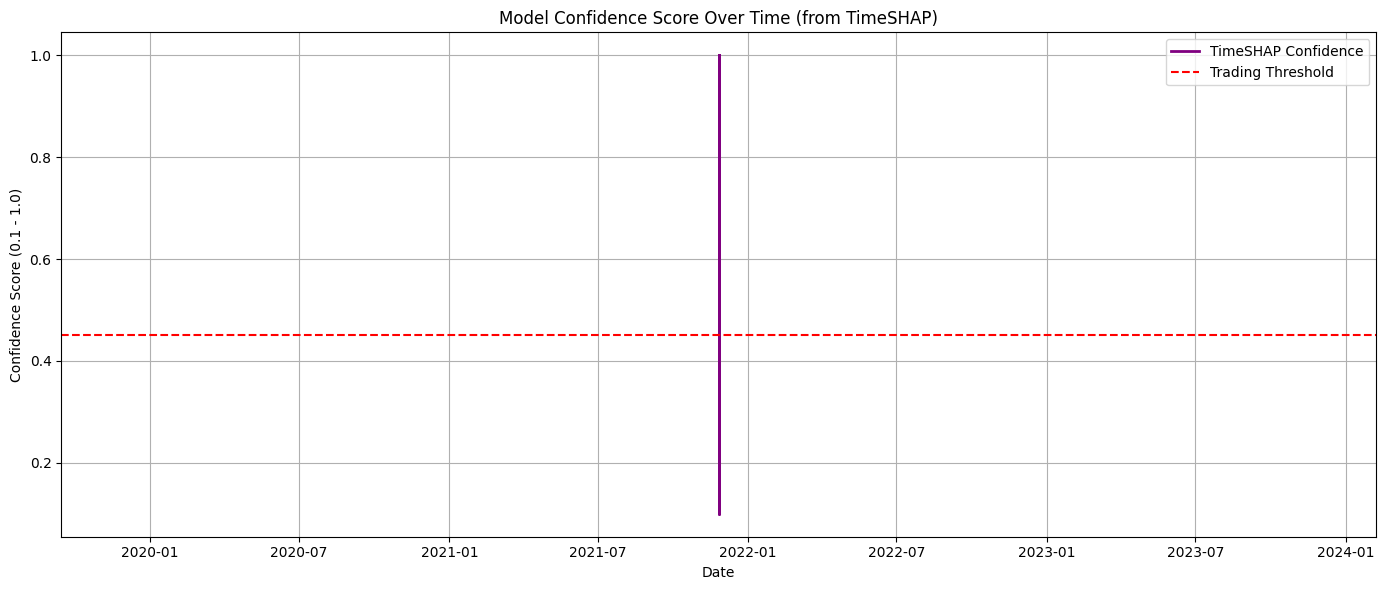

In [29]:

# After generating df_test with confidence_score
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['confidence_score'], color='purple', linewidth=2, label='TimeSHAP Confidence')
plt.title('Model Confidence Score Over Time (from TimeSHAP)')
plt.xlabel('Date')
plt.ylabel('Confidence Score (0.1 - 1.0)')
plt.axhline(y=0.45, color='red', linestyle='--', label='Trading Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/confidence_score_graph.png", dpi=200)
plt.show()